In [14]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib

In [15]:
data = pd.read_csv('data/crypto_github_events.csv')

In [16]:
data.head()

,date,actions,userID,repoID
0,2017-08-01T00:00:52Z,CreateEvent,5Nmia2cw5HiUKpI4Y7QkdQ,QpCgVmN38cAsZsguOedHRQ/ulH05knxjR0kz69FFwz0zQ
1,2017-08-01T00:01:18Z,PushEvent,_DHICgWntHlPx4gWdGpnRQ,_DHICgWntHlPx4gWdGpnRQ/vQPripJdYu4jFwApawJJVg
2,2017-08-01T00:02:08Z,PullRequestEvent,YKzvufnF_N6khw7BOhE8hg,YKzvufnF_N6khw7BOhE8hg/gnx0nGhbPbd3CVXsO0Ofkg
3,2017-08-01T00:02:43Z,PushEvent,YKzvufnF_N6khw7BOhE8hg,YKzvufnF_N6khw7BOhE8hg/gnx0nGhbPbd3CVXsO0Ofkg
4,2017-08-01T00:04:09Z,WatchEvent,HxIxl_gs5e--6UT_EHq8lw,KaOGV4oCMwLIdCEZFy2CXQ/gAwyeu-z-SQVE8v1Uau_2g


In [17]:
# get month and year only from the date column
data['month_year'] = pd.to_datetime(data['date']).dt.strftime("%Y-%m")

In [18]:
data

,date,actions,userID,repoID,month_year
0,2017-08-01T00:00:52Z,CreateEvent,5Nmia2cw5HiUKpI4Y7QkdQ,QpCgVmN38cAsZsguOedHRQ/ulH05knxjR0kz69FFwz0zQ,2017-08
1,2017-08-01T00:01:18Z,PushEvent,_DHICgWntHlPx4gWdGpnRQ,_DHICgWntHlPx4gWdGpnRQ/vQPripJdYu4jFwApawJJVg,2017-08
2,2017-08-01T00:02:08Z,PullRequestEvent,YKzvufnF_N6khw7BOhE8hg,YKzvufnF_N6khw7BOhE8hg/gnx0nGhbPbd3CVXsO0Ofkg,2017-08
3,2017-08-01T00:02:43Z,PushEvent,YKzvufnF_N6khw7BOhE8hg,YKzvufnF_N6khw7BOhE8hg/gnx0nGhbPbd3CVXsO0Ofkg,2017-08
4,2017-08-01T00:04:09Z,WatchEvent,HxIxl_gs5e--6UT_EHq8lw,KaOGV4oCMwLIdCEZFy2CXQ/gAwyeu-z-SQVE8v1Uau_2g,2017-08
...,...,...,...,...,...
1172133,2015-02-28T23:46:38Z,PushEvent,o5z_YUsRZNa7OsT-h3T-jw,o5z_YUsRZNa7OsT-h3T-jw/YQEjJe2gTo1DHv1IOldfBg,2015-02
1172134,2015-02-28T23:49:30Z,PushEvent,o5z_YUsRZNa7OsT-h3T-jw,o5z_YUsRZNa7OsT-h3T-jw/NfXs6eoZaEh01-2JR7CwRw,2015-02
1172135,2015-02-28T23:51:03Z,IssueCommentEvent,KIt2XH-wt4N4XFNfAlk5KQ,GHiveXQT9MT3otetyX0Z6g/5RniP4iUIclB2TLR6k_KJQ,2015-02
1172136,2015-02-28T23:51:23Z,IssueCommentEvent,KIt2XH-wt4N4XFNfAlk5KQ,GHiveXQT9MT3otetyX0Z6g/5RniP4iUIclB2TLR6k_KJQ,2015-02


In [19]:
# gets only users who did actions between January and December 2016
users_2016 = data[(data['month_year'] >= '2016-01') & (data['month_year'] <= '2016-12')]

In [20]:
# group by the user ID, count number of actions for each ID, and then sort with the highest values at the top
action_counts = pd.DataFrame(users_2016.groupby(by = 'userID')['actions'].count().sort_values(ascending = False))

top10_users = action_counts.iloc[0:10]
top10_users

,actions
userID,
8iDsKCYEfcL4jeGKxNtPQg,9957
K3WbcDlZUBxBfx8Mv-twSg,6071
-Tf7mnYl8kygw0ZctlhfOw,5619
M5f7BOOVxgnr-XdzMo8bGQ,4100
yhHGzBppxhIRhPkWapTLJQ,4057
Qyz97YBv9rf-V3QYWhkSbw,3525
-a6UdIyZt2IMkKkd1Msv6g,3330
AIVdQMXja0fmjFk_ejf7ow,3180
Li47SClZy_BDxLTc0mN7bQ,3041


In [21]:
# makes list of the top 10 usernames
top10_user_list = top10_users.index.to_list()
top10_user_list

# finds all rows where the userID is in the top 10, then groups by userID and month in 2016, getting the count of each action per month per user
# unstack pivots the dataframe from being long to being wide
# .loc[top10_user_list] sorts the rows by total action count
top10_months = pd.DataFrame(users_2016[users_2016['userID'].isin(top10_users.index)].groupby(by = ['userID', 'month_year'])['actions'].count().unstack().loc[top10_user_list])

# save to csv file
top10_months.to_csv('top10_monthly_counts.csv')

In [22]:
top10_months

month_year,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12
userID,,,,,,,,,,,,
8iDsKCYEfcL4jeGKxNtPQg,78.0,1292.0,745.0,738.0,1183.0,731.0,888.0,1188.0,1090.0,719.0,755.0,550.0
K3WbcDlZUBxBfx8Mv-twSg,395.0,600.0,645.0,721.0,370.0,648.0,344.0,424.0,718.0,410.0,474.0,322.0
-Tf7mnYl8kygw0ZctlhfOw,100.0,468.0,357.0,195.0,522.0,393.0,442.0,597.0,634.0,508.0,709.0,694.0
M5f7BOOVxgnr-XdzMo8bGQ,523.0,196.0,402.0,429.0,285.0,379.0,257.0,412.0,461.0,234.0,261.0,261.0
yhHGzBppxhIRhPkWapTLJQ,125.0,365.0,294.0,336.0,508.0,265.0,159.0,311.0,570.0,417.0,349.0,358.0
Qyz97YBv9rf-V3QYWhkSbw,NaN,NaN,NaN,8.0,958.0,240.0,481.0,422.0,309.0,248.0,390.0,469.0
-a6UdIyZt2IMkKkd1Msv6g,31.0,417.0,267.0,254.0,379.0,318.0,361.0,466.0,401.0,217.0,141.0,78.0
AIVdQMXja0fmjFk_ejf7ow,164.0,179.0,254.0,372.0,335.0,452.0,196.0,367.0,236.0,100.0,270.0,255.0
Li47SClZy_BDxLTc0mN7bQ,268.0,247.0,223.0,418.0,324.0,396.0,379.0,280.0,131.0,42.0,143.0,190.0


In [23]:
# get top 5 users for the graph
top5_users = top10_months.iloc[0:5]
top5_users

month_year,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12
userID,,,,,,,,,,,,
8iDsKCYEfcL4jeGKxNtPQg,78.0,1292.0,745.0,738.0,1183.0,731.0,888.0,1188.0,1090.0,719.0,755.0,550.0
K3WbcDlZUBxBfx8Mv-twSg,395.0,600.0,645.0,721.0,370.0,648.0,344.0,424.0,718.0,410.0,474.0,322.0
-Tf7mnYl8kygw0ZctlhfOw,100.0,468.0,357.0,195.0,522.0,393.0,442.0,597.0,634.0,508.0,709.0,694.0
M5f7BOOVxgnr-XdzMo8bGQ,523.0,196.0,402.0,429.0,285.0,379.0,257.0,412.0,461.0,234.0,261.0,261.0
yhHGzBppxhIRhPkWapTLJQ,125.0,365.0,294.0,336.0,508.0,265.0,159.0,311.0,570.0,417.0,349.0,358.0


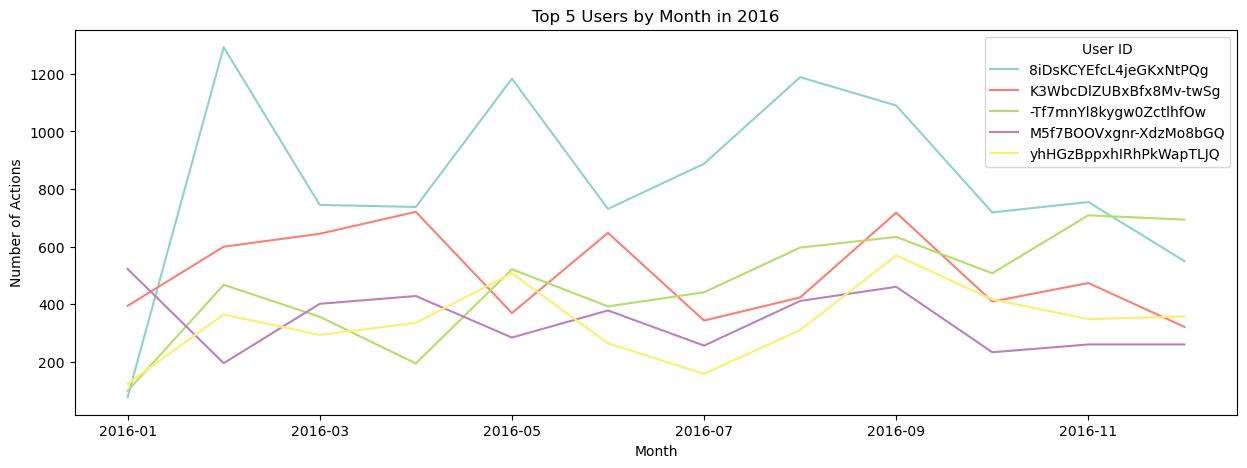

In [24]:
# swap rows and columns with T
# plot and change label names
top5_graph = top5_users.T.plot(
    figsize = (15, 5),
    title = 'Top 5 Users by Month in 2016',
    xlabel = 'Month',
    ylabel = 'Number of Actions',
    colormap = 'Set3'
)

# change legend title
top5_graph.legend(title = 'User ID')

plt.savefig('Top 5 Users')
plt.show()

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
from numpy import dot
from numpy.linalg import norm

In [27]:
# cosine similarity using sklean function
top2_users = top5_users.iloc[:2]
cosine_similarity(top2_users)

array([[1.        , 0.91812623],
       [0.91812623, 1.        ]])

In [28]:
# cosine similarity using the formula and numpy
user1 = top2_users.iloc[0].tolist()
user2 = top2_users.iloc[1].tolist()

cosine_sim = dot(user1,user2) / (norm(user1)*norm(user2))
print(cosine_sim)

0.9181262305329296


In [29]:
from sklearn.metrics.pairwise import euclidean_distances

In [30]:
# euclidean distance using sklearn function
euclidean_distances(top2_users)

array([[   0.        , 1581.75282519],
       [1581.75282519,    0.        ]])

## Bonus

In [31]:
# transpose again so userID is the column
# corr is the built-in function
top2_users.T.corr()

userID,8iDsKCYEfcL4jeGKxNtPQg,K3WbcDlZUBxBfx8Mv-twSg
userID,,
8iDsKCYEfcL4jeGKxNtPQg,1.000000,0.207464
K3WbcDlZUBxBfx8Mv-twSg,0.207464,1.000000


In [54]:
import seaborn as sns
import numpy as np

In [55]:
# get top 6 users and their correlation with built-in corr function
top6_users = top10_months.iloc[0:6]
top6_corr = top6_users.T.corr()
top6_corr

userID,8iDsKCYEfcL4jeGKxNtPQg,K3WbcDlZUBxBfx8Mv-twSg,-Tf7mnYl8kygw0ZctlhfOw,M5f7BOOVxgnr-XdzMo8bGQ,yhHGzBppxhIRhPkWapTLJQ,Qyz97YBv9rf-V3QYWhkSbw
userID,,,,,,
8iDsKCYEfcL4jeGKxNtPQg,1.000000,0.207464,0.493986,-0.386258,0.579829,0.503629
K3WbcDlZUBxBfx8Mv-twSg,0.207464,1.000000,-0.244449,0.389437,0.263534,-0.652677
-Tf7mnYl8kygw0ZctlhfOw,0.493986,-0.244449,1.000000,-0.527445,0.569957,0.432994
M5f7BOOVxgnr-XdzMo8bGQ,-0.386258,0.389437,-0.527445,1.000000,-0.190823,-0.423934
yhHGzBppxhIRhPkWapTLJQ,0.579829,0.263534,0.569957,-0.190823,1.000000,0.244609
Qyz97YBv9rf-V3QYWhkSbw,0.503629,-0.652677,0.432994,-0.423934,0.244609,1.000000


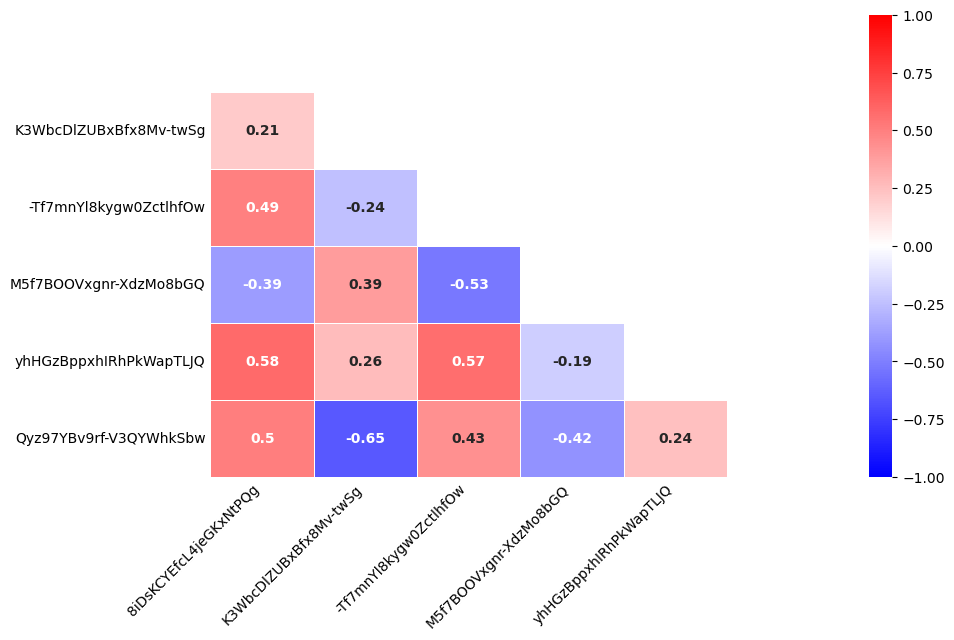

In [58]:
# mask to only show lower triangle of heatmap
mask = np.triu(top6_corr)

# annot shows numbers in squares, vmin and vmax adjust the scale, and cmap is the color palette I chose (bwr)
# annot_kws makes text bold, line width puts visible lines between squares
plt.figure(figsize = [10, 6])
sns.heatmap(
    top6_corr,
    mask = mask,
    annot = True,
    vmin = -1,
    vmax = 1,
    cmap = 'bwr',
    annot_kws = {'weight': 'bold'},
    linewidth = 0.5
)

ax = plt.gca()
# remove tick marks
ax.tick_params(length = 0)
# remove x and y labels
ax.set(xlabel = None, ylabel = None)
# rotate x axis tick labels 45 degree to be more readable, and remove x axis tick label for empty column
ax.set_xticks(ax.get_xticks()[:-1], labels = top6_corr.columns[:-1], ha = 'right', rotation = 45)
# remove y axis tick label for empty row
ax.set_yticks(ax.get_yticks()[1:], labels = top6_corr.columns[1:])

plt.show()